# 03 - Exploratory data analysis

Each table or figure answers one question:
1. How are returns distributed at 1 min / 15 min / 1 h / 1 day, and how heavy are the tails?
2. Are hourly returns autocorrelated, i.e. predictable from their own past? Does volatility cluster? *(development data only)*
3. How are volume and returns related, both in the same hour and the next hour? *(development data only)*
4. Is there intraday seasonality in volatility and volume?
5. Which volatility and trend regimes occurred, and when were the extreme hours?

**Rule:** anything relating the past to *future* returns uses development data (before 2024) only, so the test period stays untouched.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))
import pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
import run_pipeline as rp
from src import config
T, F = config.TABLES_DIR, config.FIGURES_DIR
SYMBOL = config.SYMBOL
# False (default): display the outputs saved by scripts/run_pipeline.py.
# True re-computes the stage. Do NOT re-run 'validation' or 'test' casually:
# validation resets the experiment log and every test run adds a TEST row.
RUN_STAGE = False
def show(name, **kw):
    display(Markdown(f"**{name}**")); display(pd.read_csv(T / name, **kw))
def fig(name):
    display(Image(filename=str(F / name)))
def results(section):
    return json.loads((config.REPORTS_DIR / "results.json").read_text()).get(section, {})

In [2]:
if RUN_STAGE:
    rp.stage_eda(SYMBOL)

In [3]:
show('eda_return_distribution.csv')

**eda_return_distribution.csv**

,horizon,n,mean_pct,std_pct,skew,excess_kurtosis,min_pct,max_pct,share_beyond_4sd,normal_share_beyond_4sd,jarque_bera_p
0,1 min,4767643,0.000050,0.110302,0.071674,124.939669,-7.510582,7.229275,0.009122,0.000063,0.0
1,15 min,317802,0.000743,0.388780,-0.006401,74.837671,-14.124090,20.399154,0.008757,0.000063,0.0
2,1 hour,79414,0.002859,0.757063,-0.486160,37.983026,-20.103321,16.028033,0.009230,0.000063,0.0
3,1 day,3254,0.059859,3.480357,-1.125050,16.890217,-50.260694,17.844856,0.005532,0.000063,0.0


In [4]:
show('eda_dependence_dev.csv')

**eda_dependence_dev.csv**

,series,acf_lag1,acf_lag2,acf_lag3,acf_lag6,acf_lag12,acf_lag24,ljung_box_lag,ljung_box_p
0,return,-0.047077,-0.032816,-0.000921,-0.014980,0.008430,-0.044724,24,9.087065e-72
1,|return|,0.306891,0.283227,0.265291,0.240340,0.232438,0.214999,24,0.000000e+00
2,return^2,0.177661,0.187843,0.193136,0.091601,0.083198,0.061126,24,0.000000e+00


In [5]:
show('eda_volume_return_dev.csv')

**eda_volume_return_dev.csv**

,question,spearman,naive_p,n
0,same-hour volume vs |return|,0.406370,0.000000e+00,54940
1,volume now vs next-hour |return|,0.176290,0.000000e+00,54940
2,volume now vs next-hour return,0.012269,4.030100e-03,54940
3,return now vs next-hour return,-0.079077,6.311369e-77,54940


In [6]:
show('eda_intraday_dev.csv')

**eda_intraday_dev.csv**

,hour,mean_abs_ret_pct,mean_ret_bp,rel_volume
0,0,0.575140,1.429821,1.064666
1,1,0.493976,-2.127886,0.948668
2,2,0.449203,-2.952059,0.903342
3,3,0.413775,-3.191671,0.872174
4,4,0.404724,-1.200495,0.859091
5,5,0.406927,0.079272,0.863431
6,6,0.415974,1.879729,0.894754
7,7,0.440054,1.088975,0.959458
8,8,0.471926,-0.319395,1.050048
9,9,0.456302,-2.088980,1.025296


In [7]:
show('eda_regimes_by_year.csv')

**eda_regimes_by_year.csv**

,open_time,high_vol_share,trending_share,mean_hourly_vol_pct
0,2017,0.227162,0.245432,1.284618
1,2018,0.252968,0.304566,0.842316
2,2019,0.293037,0.289498,0.579140
3,2020,0.374545,0.299522,0.596683
4,2021,0.327397,0.312671,0.825464
5,2022,0.285731,0.294977,0.592092
6,2023,0.356507,0.273630,0.389529
7,2024,0.375797,0.301230,0.506631
8,2025,0.332192,0.288813,0.418889
9,2026,0.272436,0.316545,0.408625


In [8]:
show('eda_extreme_hours.csv')

**eda_extreme_hours.csv**

,open_time,ret_pct,close,volume
0,2017-09-05 01:00:00+00:00,-9.981784,3620.00,99.245285
1,2017-09-05 02:00:00+00:00,11.325716,4054.11,53.837624
2,2017-09-15 12:00:00+00:00,13.173121,3330.00,207.783644
3,2017-09-15 14:00:00+00:00,11.777708,3780.00,200.614882
4,2017-12-22 13:00:00+00:00,-10.785822,12020.04,2045.092438
5,2017-12-28 02:00:00+00:00,-10.809658,13822.13,2163.698314
6,2018-01-17 16:00:00+00:00,10.879035,10287.97,4679.583691
7,2018-04-12 11:00:00+00:00,10.332531,7690.00,16480.893133
8,2018-10-15 06:00:00+00:00,10.072696,7410.03,17721.945753
9,2020-03-12 10:00:00+00:00,-20.103321,6014.90,28792.656130


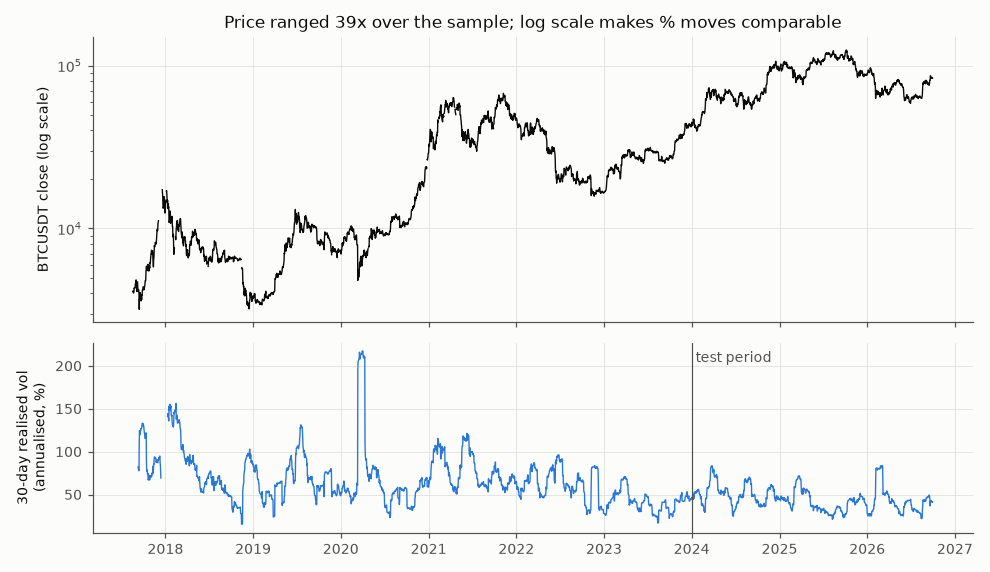

In [9]:
fig('eda_price_volatility.png')

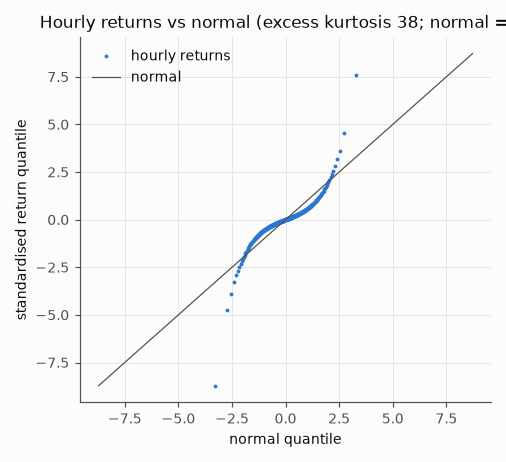

In [10]:
fig('eda_hourly_return_qq.png')

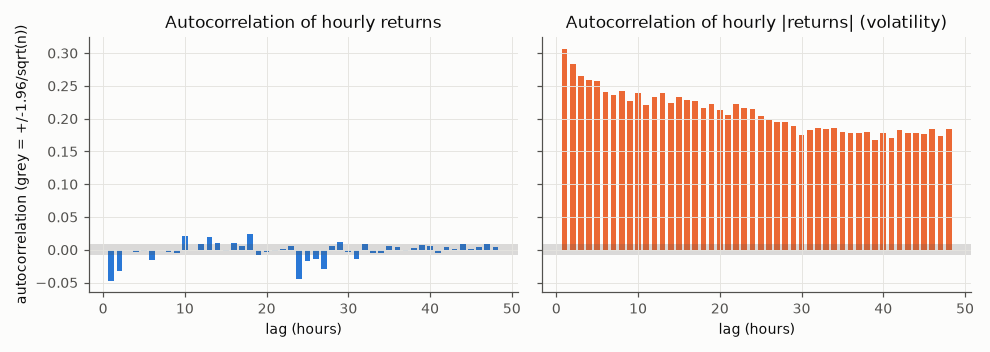

In [11]:
fig('eda_acf_dev.png')

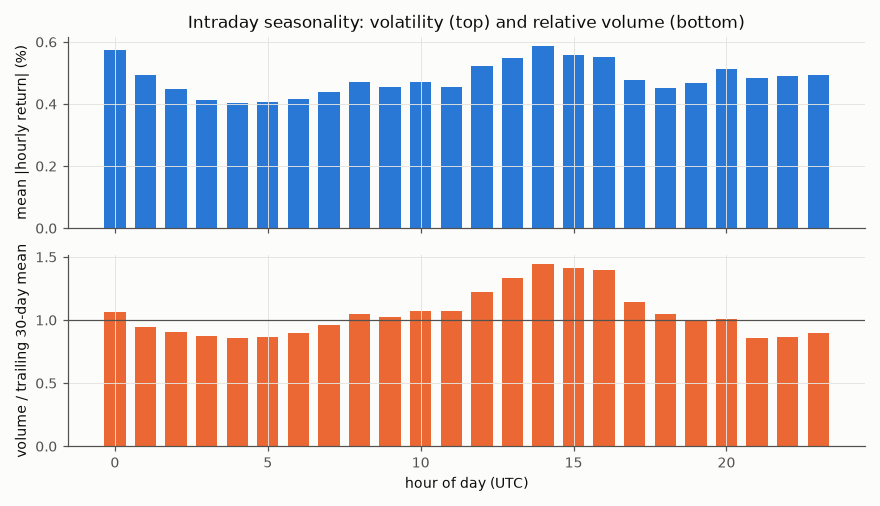

In [12]:
fig('eda_intraday_dev.png')

**Interpretation:** see the matching section of `reports/final_report.md`, written from these outputs.